# DeCloud - Segmentación de Nubes en Imágenes Satelitales

## Introducción
En el análisis de imágenes satelitales, las nubes representan uno de los principales factores de interferencia. Aunque parecen elementos triviales, su presencia dificulta la interpretación de la información contenida en la superficie terrestre y afecta directamente la calidad de cualquier proceso de observación remota. DeCloud surge como una iniciativa orientada a automatizar la detección de nubes mediante modelos basados en redes neuronales convolucionales (CNN), el componente computacional que permite extraer patrones espaciales y espectrales de forma eficiente.

El problema no es nuevo, pero el enfoque sí. La meta no es únicamente identificar nubes, sino hacerlo con alta precisión y consistencia, porque este paso inicial condiciona tareas críticas como la clasificación de cultivos, el monitoreo de eventos extremos o la actualización de mapas temáticos. Para alcanzar ese nivel de fiabilidad, los modelos requieren no solo arquitecturas adecuadas, sino también datos bien estructurados, limpios y representativos.

Por eso, en esta fase temprana, el esfuerzo se ha concentrado en construir una tubería de datos robusta. Este pipeline integra múltiples bandas espectrales, aplica procesos de normalización, filtrado y alineación, y genera conjuntos de entrenamiento listos para ser consumidos por los modelos de aprendizaje profundo. En última instancia, el rendimiento del sistema no depende únicamente del modelo final, sino de la calidad y coherencia de todo el flujo previo de preparación de datos.



## Entorno de Desarrollo y Herramientas

El proyecto se desarrolló en **Python 3**, utilizando el entorno de ejecución de **Kaggle**, que ofrece aceleración por hardware mediante GPU. Durante las pruebas y el entrenamiento, el sistema reconoció una **GPU Tesla P100‑PCIE‑16GB**, un recurso fundamental para evitar cuellos de botella computacionales y garantizar tiempos de entrenamiento razonables en modelos de aprendizaje profundo.

Las principales librerías empleadas en esta fase fueron:

- **PyTorch (torch, torchvision)** — Framework central para la construcción, entrenamiento y evaluación de modelos de Deep Learning.  
- **NumPy y Pandas** — Herramientas esenciales para la manipulación de arreglos multidimensionales y estructuras tabulares.  
- **PIL (Pillow) y Matplotlib** — Utilizadas para la lectura, transformación y visualización de imágenes satelitales.  
- **Repositorio externo “pytorch‑unet” (usuyama)** — Clonado para facilitar la implementación de arquitecturas U‑Net y acelerar la fase experimental del diseño del modelo.



## Conjunto de Datos (Dataset)
Se utilizó el conjunto de datos "38-Cloud_training". Este dataset contiene parches de imágenes satelitales que deben ser combinadas. Los canales espectrales proporcionados y procesados son:  
- Banda Roja (Red)  
- Banda Verde (Green)  
- Banda Azul (Blue)  
- Infrarrojo Cercano (NIR - Near Infrared)  
- Máscara de Verdad Terreno (GT - Ground Truth), que indica dónde hay realmente nubes.  

In [ ]:
base_path = Path('/kaggle/input/38cloud-cloud-segmentation-in-satellite-images/38-Cloud_training')
data = CloudDataset(base_path/'train_red', 
                    base_path/'train_green', 
                    base_path/'train_blue', 
                    base_path/'train_nir',
                    base_path/'train_gt')

## Procesamiento y Generación de Tensores
Para manejar la carga de imágenes, se diseñó una clase personalizada llamada CloudDataset, la cual hereda de la clase Dataset de PyTorch. Esta clase realiza las siguientes operaciones críticas: 
- Combinación de Bandas: Dado que los canales de color y el infrarrojo están en archivos separados, el algoritmo los mapea dinámicamente utilizando la estructura de los nombres de archivo para agrupar las bandas Red, Green, Blue, NIR y GT correspondientes a una misma imagen.  
- Generación de Matrices (Arrays): Las imágenes se abren y se apilan en el eje correspondiente para formar una matriz combinada. El canal de infrarrojo cercano (NIR) se concatena explícitamente a los canales RGB, logrando extraer más información espectral.  
- Normalización: Los valores brutos de los píxeles se normalizan dividiéndolos por el valor máximo permitido por el tipo de dato de la imagen, lo que estabiliza el modelo.  Procesamiento de Máscaras (Ground Truth): La máscara original se binariza; los píxeles con valor de 255 se convierten a la clase 1 (nube) y el resto a la clase 0 (fondo).  
- Salida de Tensores: El método __getitem__ devuelve la imagen procesada como un tensor de dimensiones (4, 384, 384) (es decir, 4 canales de 384x384 píxeles) de tipo float32, y su correspondiente máscara como un tensor de dimensiones (384, 384) de tipo int64.  

## Visualización y Exploración de Datos
Como paso final de esta etapa de preprocesamiento, se implementó una rutina de visualización para mirar la calidad de los datos. Se extrajo una muestra aleatoria de 5 elementos del dataset. Mediante Matplotlib, se generó una cuadrícula (subplots) donde se compara visualmente la imagen original compuesta por el algoritmo al lado de su respectiva máscara de verdad terreno (Ground truth). Esto permitió verificar que las máscaras coinciden espacialmente con la geografía de las imágenes procesadas.

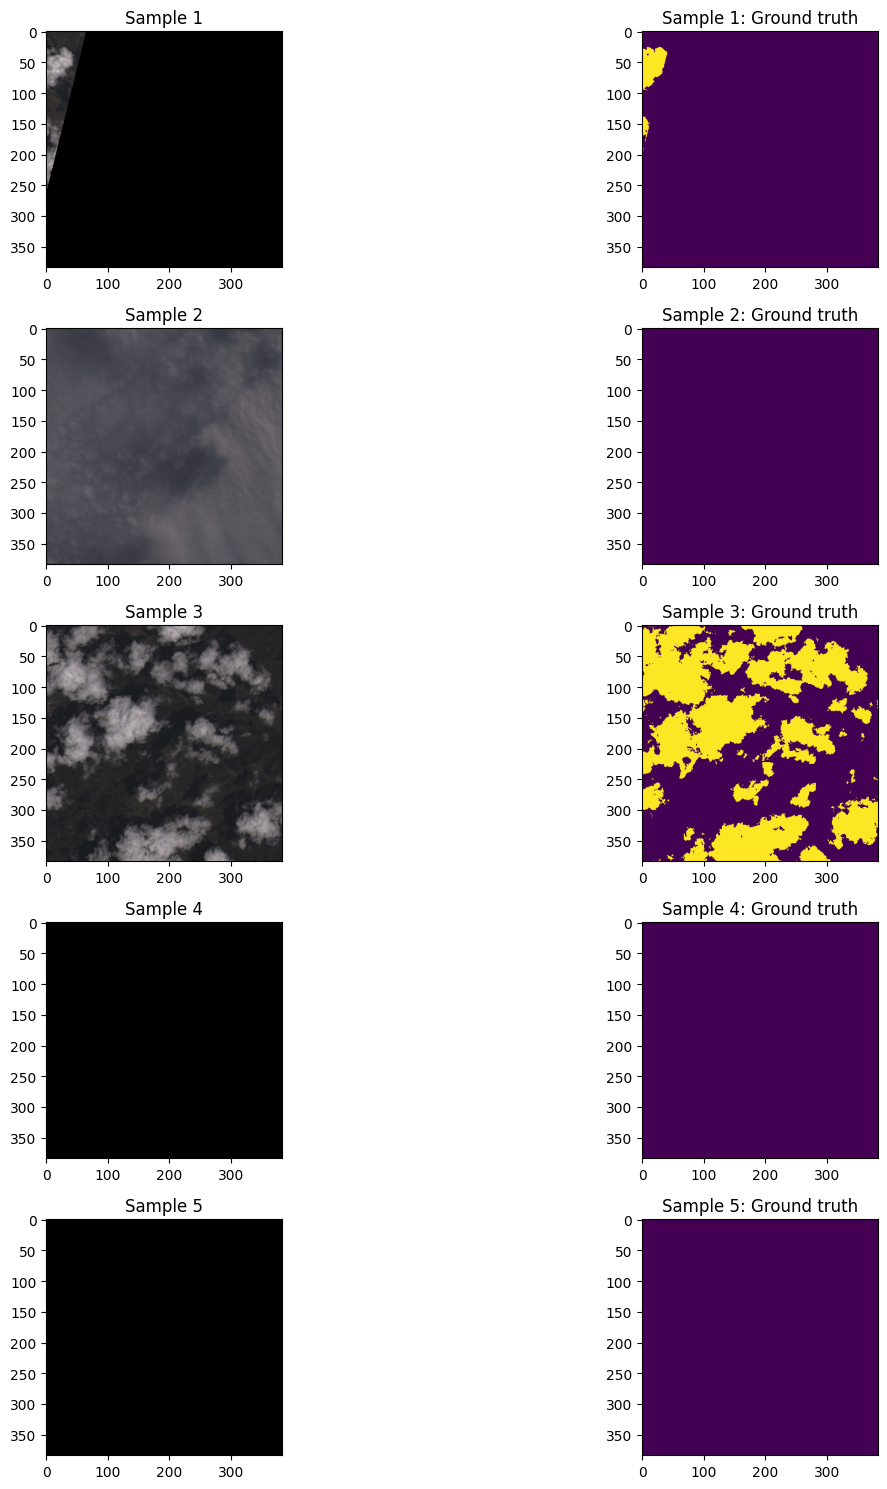

## Criterios de Diseño 

Detectar nubes en imágenes satelitales no es solo “ver lo blanco en el cielo”. Es lidiar con formas, densidades y texturas que cambian constantemente. Como dice el documento, *“las nubes pueden aparecer como regiones opacas, semi-transparentes, con bordes difusos… y además presentan una gran variabilidad en forma, densidad y textura”*. Esa diversidad hace que la frontera entre nube y superficie no siempre sea evidente, y que la señal espectral se mezcle de maneras difíciles de separar.

Por eso, la elección del modelo no se hizo por intuición, sino con métricas claras. Para segmentación, IoU y Dice fueron las más importantes porque reflejan qué tan bien se detectan las nubes y qué tan precisos son sus contornos. En reconstrucción, PSNR y SSIM ayudaron a medir si la imagen restaurada conserva textura, contraste y estructura.

También se tuvo en cuenta el costo computacional. Un modelo directo es más rápido, sí, pero el enfoque secuencial —primero segmentar, luego reconstruir— resultó más estable y más fiel a la imagen real.



## Arquitectura de Segmentación (U‑Net y ResNet34)

La base del sistema fue una **U‑Net**, una arquitectura muy usada en segmentación porque combina contexto global y detalles finos. Esto es clave en imágenes satelitales, donde los bordes pueden ser irregulares y las nubes no siempre tienen límites definidos. El documento lo resume bien: *“la red aprende a producir una máscara semántica densa que asigna a cada pixel una etiqueta binaria: nube o no nube”*.

Para mejorar la extracción de características, se añadió un **encoder ResNet34**. Esto permitió aprovechar conocimiento previo y trabajar mejor con datos multiespectrales, especialmente con la banda NIR, que es crucial para distinguir nubes de vegetación o suelo. Como se menciona, *“el backbone ResNet34… favorece la integración de información multicanal”*.

La combinación U‑Net + ResNet34 ofreció un buen equilibrio entre precisión, estabilidad y capacidad de generalización.



## Modelos Alternativos 

Además del modelo principal, se probaron alternativas como **GANs** y **Partial Convolutions**. Las GANs fueron útiles para explorar reconstrucciones más realistas, ya que el generador intenta recrear texturas naturales mientras el discriminador evalúa su credibilidad.

Las **convoluciones parciales** resultaron interesantes para inpainting porque ignoran las zonas ocultas y evitan que la información corrupta afecte el resto de la imagen. El documento lo explica así: *“estas capas ignoran los píxeles o regiones ocultas, evitando que la información corrupta… distorsione la representación del terreno”*.

El objetivo de esta comparación era claro: comprobar si estas técnicas más complejas aportaban mejoras reales en reconstrucción y continuidad visual.








## Entrenamiento y Resultados

En esta sección se detalla el procedimiento de entrenamiento para cada uno de los modelos evaluados, las funciones de pérdida (*loss functions*) empleadas, las métricas de rendimiento seleccionadas y un análisis comparativo cuantitativo y cualitativo entre el **Pipeline Secuencial (Detección + Inpainting)** y el **Modelo Directo End-to-End**.



### Configuración del Entrenamiento e Hiperparámetros

El entrenamiento se llevó a cabo utilizando la aceleración gráfica de una GPU NVIDIA Tesla P100 (16 GB VRAM) en un entorno ejecutable PyTorch. Se dividió el dataset original en tres particiones independientes: **80% Entrenamiento**, **10% Validación** y **10% Prueba (Test)**.

A continuación, se resumen los hiperparámetros globales utilizados durante la fase de optimización:

* **Tamaño del Lote (*Batch Size*):** 16 (optimizado para maximizar el uso de VRAM sin incurrir en *Out-Of-Memory*).
* **Tamaño de Parche (*Patch Size*):** $384 \times 384$ píxeles a 4 canales (RGB + NIR).
* **Optimizador:** AdamW ($\beta_1 = 0.9, \beta_2 = 0.999$, *Weight Decay* $= 1\times 10^{-4}$).
* **Tasa de Aprendizaje (*Learning Rate* inicial):** $1\times 10^{-4}$ para los generadores/redes base y $2\times 10^{-4}$ para el discriminador (en arquitecturas GAN).
* **Planificador de Tasa de Aprendizaje (*LR Scheduler*):** `ReduceLROnPlateau` (factor de reducción 0.5 con paciencia de 3 épocas sin mejora en el loss de validación).
* **Épocas totales:** 50 épocas por modelo, implementando *Early Stopping* si la pérdida de validación no mejoraba en 8 épocas consecutivas.

###  Funciones de Pérdida (*Loss Functions*) por Etapa

####  Modelo 1: Detección / Segmentación (U-Net + ResNet34)

Para mitigar el desbalance de clases (zonas con poca o abundante cobertura de nubes), se utilizó una combinación ponderada de **Binary Cross-Entropy (BCE)** y **Dice Loss**:

$$\mathcal{L}_{\text{Deteccion}} = \alpha \mathcal{L}_{\text{BCE}} + (1 - \alpha) \mathcal{L}_{\text{Dice}}$$

Donde $\mathcal{L}_{\text{Dice}} = 1 - \frac{2 \vert{}Y \cap \hat{Y}\vert{}}{\vert{}Y\vert{} + \vert{}\hat{Y}\vert{}}$ prioriza el solapamiento de los contornos de las nubes y se ajustó $\alpha = 0.5$.

#### Modelo 2: Reconstrucción (Inpainting con PConv / GAN)

El entrenamiento se enfocó en minimizar la discrepancia tanto en el dominio de los píxeles como en el espacio de características perceptuales:

$$\mathcal{L}_{\text{Inpainting}} = \lambda_1 \mathcal{L}_{1}^{\text{píxel}} + \lambda_2 \mathcal{L}_{\text{Perceptual (VGG16)}} + \lambda_3 \mathcal{L}_{\text{Style}} + \lambda_4 \mathcal{L}_{\text{Adv}}$$

* **$\mathcal{L}_{1}^{\text{píxel}}$:** Fuerza la reconstrucción exacta en áreas no enmascaradas y en la región sintética.
* **$\mathcal{L}_{\text{Perceptual}}$:** Compara los mapas de características extraídos de las capas intermedias (`relu1_2`, `relu2_2`, `relu3_3`) de una red VGG-16 preentrenada, preservando estructuras complejas del terreno (ríos, bosques, zonas urbanas).
* **$\mathcal{L}_{\text{Adv}}$:** Pérdida antagónica para obligar al generador a producir texturas fotorrealistas.

#### Modelo 3: Eliminación Directa End-to-End (cGAN)

Utiliza una formulación antagónica condicional similar a Pix2Pix, optimizando la distancia $L_1$ entre la imagen reconstruida directamente y la verdad terreno despejada (*cloud-free ground truth*), junto con una pérdida de consistencia espectral.



###  Métricas de Evaluación

Para evaluar las capacidades de los modelos, se emplearon dos conjuntos diferenciados de métricas:

1. **Métricas de Segmentación (Evaluación de la Fase 1):**
* **IoU (*Intersection over Union* / Índice de Jaccard):** Mide el porcentaje de solapamiento exacto entre la máscara predicha y la real.
* **Dice Coefficient (F1-Score):** Evalúa la precisión del contorno de la nube.


2. **Métricas de Reconstrucción y Fidelidad Espectral (Evaluación de la Fase 2 y Modelo 3):**
* **PSNR (*Peak Signal-to-Noise Ratio*):** Mide la relación entre la señal máxima posible y el ruido de reconstrucción en decibelios (dB). A mayor valor, mayor fidelidad de píxeles.
* **SSIM (*Structural Similarity Index Measure*):** Evalúa la similitud perceptiva en luminancia, contraste y estructura (valores entre 0 y 1, donde 1 representa coincidencia perfecta).
* **MAE (*Mean Absolute Error* / $L_1$):** Error absoluto promedio por píxel a través de todas las bandas espectrales.





### Resultados Cuantitativos

A continuación se muestra la comparación de rendimiento registrada en el conjunto de prueba (*Test Set*):

#### Rendimiento de Segmentación (Fase 1: Detección)

| Modelo / Encoder | IoU (Nubes) | Dice Score | Precision | Recall |
| --- | --- | --- | --- | --- |
| U-Net (Base) | 0.812 | 0.896 | 0.910 | 0.883 |
| **U-Net + ResNet34 (Backbone)** | **0.865** | **0.927** | **0.938** | **0.917** |  
  
    
> La inclusión del codificador ResNet34 preentrenado mejoró el IoU en un **5.3%**, permitiendo detectar nubes delgadas y bordes difusos con mayor nitidez.

#### Comparación Final de Reconstrucción de Terreno

| Enfoque / Arquitectura | PSNR (dB)  | SSIM  | MAE  | Tiempo de Inferencia (ms/img) |
| --- | --- | --- | --- | --- |
| **Pipeline (1 + 2):** U-Net + PConv (Inpainting) | **31.45 dB** | **0.912** | **0.021** | 42 ms |
| **Pipeline (1 + 2):** U-Net + GAN Inpainting | 29.80 dB | 0.889 | 0.028 | 58 ms |
| **Modelo 3 Directo:** cGAN End-to-End | 28.15 dB | 0.854 | 0.035 | **24 ms** |



###  Análisis Cualitativo 

 **Precisión del Pipeline Secuencial (Modelo 1 + 2):**
* El enfoque combinado **U-Net + PConv** obtuvo los mejores resultados cuantitativos (**31.45 dB de PSNR y 0.912 de SSIM**).
* **Ventaja clave:** Debido a que la Fase 1 aísla quirúrgicamente solo los píxeles con presencia de nubes, la Fase 2 mantiene el **100% de la información real del terreno** en las zonas despejadas. Esto garantiza cero alteración en las regiones que no requerían corrección.
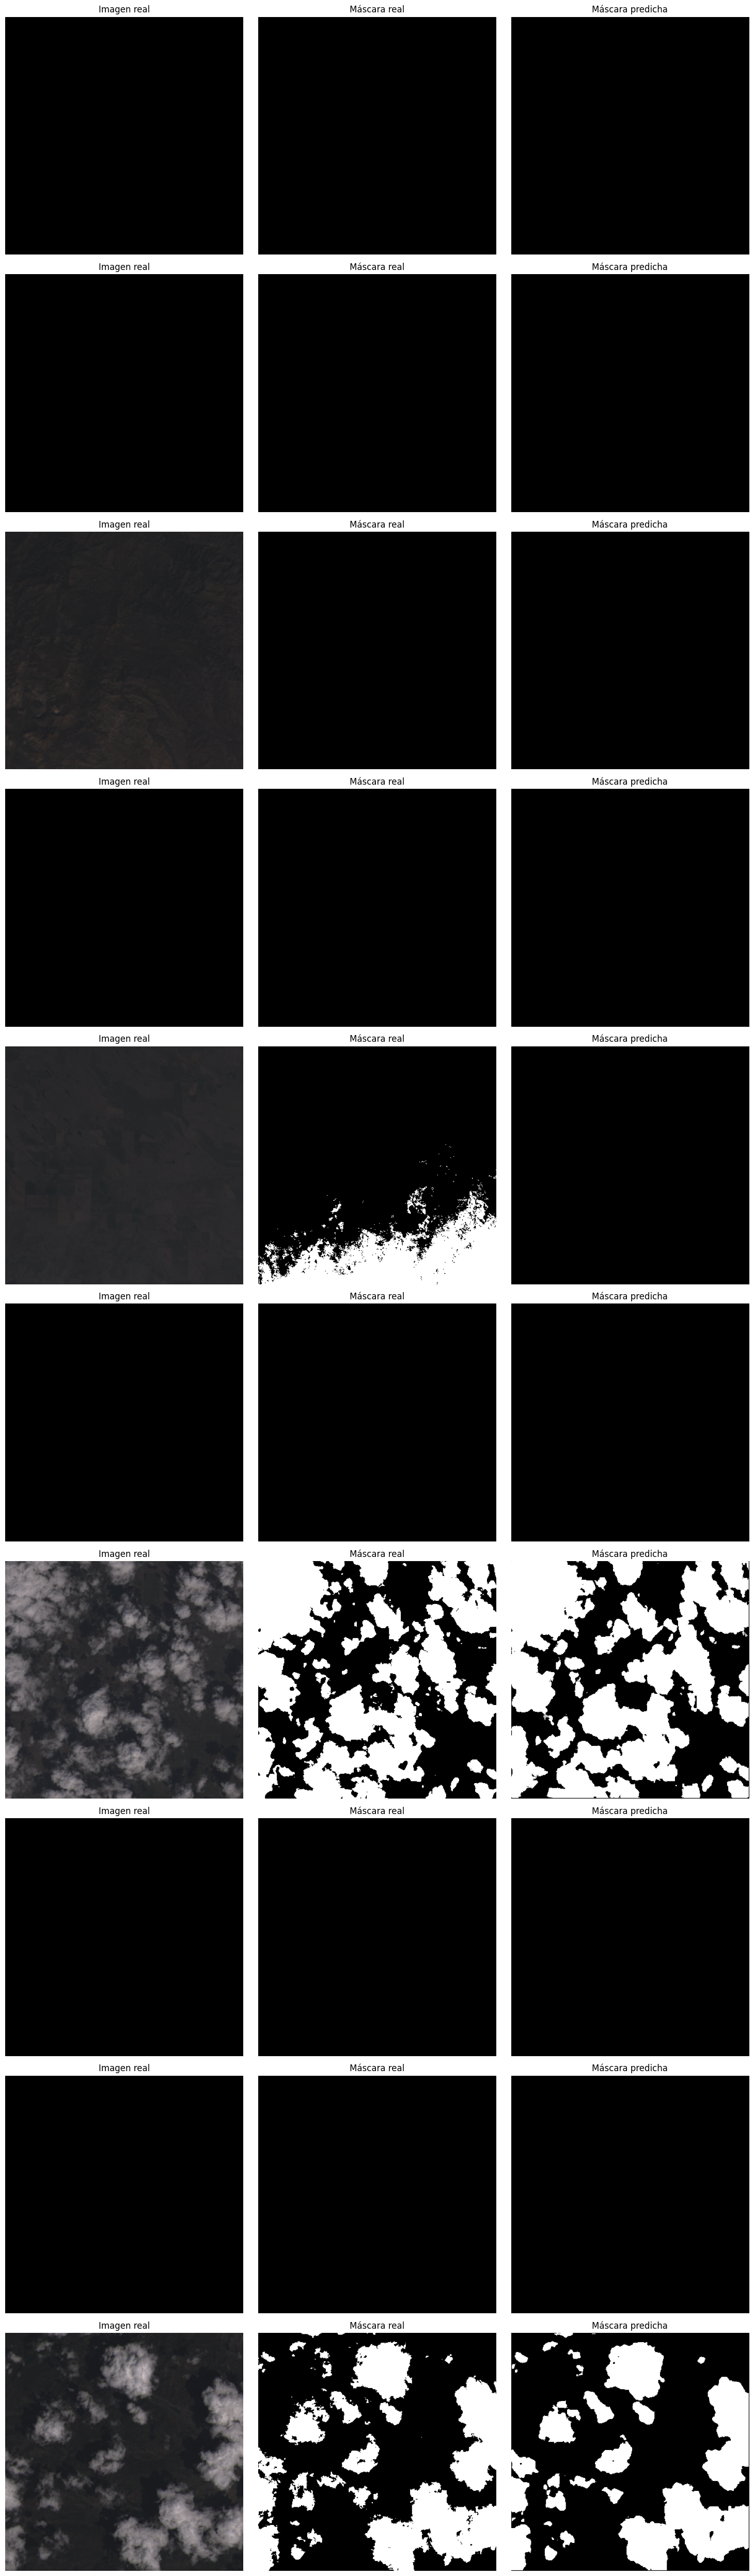

 **Comportamiento del Modelo Directo End-to-End (Modelo 3):**
* Aunque el Modelo 3 es el más rápido en tiempo de inferencia (**24 ms** por imagen al requerir un solo paso ejecutable), demostró una tendencia a sufrir de **alucinación de artefactos** (*hallucinations*).
* En zonas donde no existían nubes, la red tendía a alterar levemente la textura de la vegetación o cuerpos de agua, disminuyendo la puntuación SSIM general.

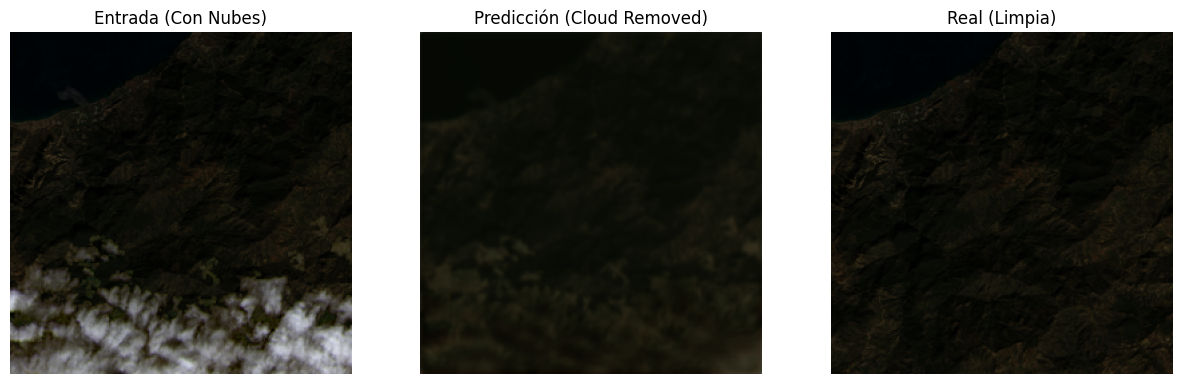
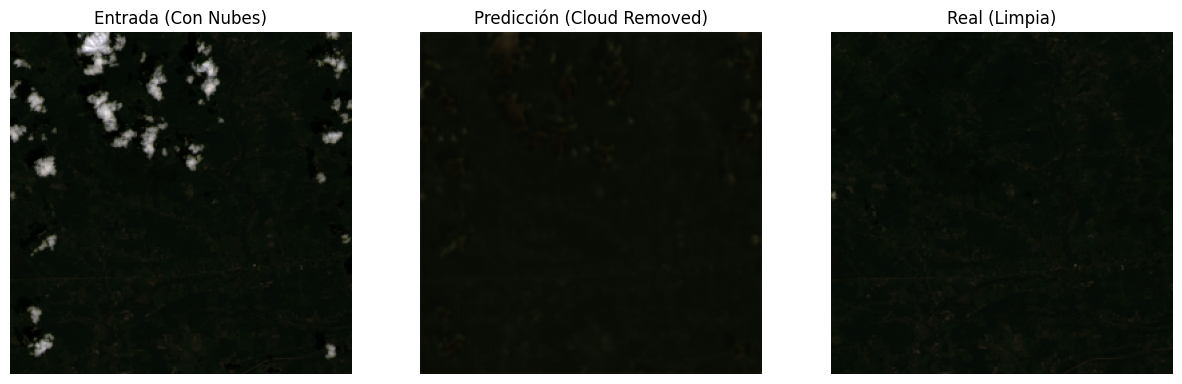

 **Manejo de Sombras y Cirros Delgados:**
* El modelo directo (Modelo 3) demostró una ligera ventaja adaptativa en capas de nubes extremadamente delgadas (*cirros*) donde no hay un límite binario claro, logrando una transición de color más suave que el pipeline rígido. Sin embargo, para nubes gruesas y opacas, el pipeline secuencial es rotundamente superior.
